In [1]:

%pip install "pandas" "numpy" "matplotlib" "scipy" "deap" "pulp" "ortools " "plotly" "scikit-learn" "seaborn" "ucimlrepo>=0.0.7" "folium" "requests"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path
import importlib

# Set project root to the notebooks directory (parent of src)
project_root = Path("/mnt/c/Users/hp/OneDrive/SLIIT/IT5082/Assignment/IT-5082-OptimizationMethods/notebooks")
sys.path.insert(0, str(project_root))
print(f"Project root added to path: {project_root}")


Project root added to path: /mnt/c/Users/hp/OneDrive/SLIIT/IT5082/Assignment/IT-5082-OptimizationMethods/notebooks


In [3]:
import warnings

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

In [4]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import requests

In [5]:

import src.config as config_module
importlib.reload(config_module)

import src.constraints as constraints_module
import src.utils as utils_module
import src.dataloader as dataloader_module
import src.mipsolver as mipsolver_module
import src.ga_solver as ga_solver_module

importlib.reload(constraints_module)
importlib.reload(utils_module)
importlib.reload(dataloader_module)
importlib.reload(mipsolver_module)
importlib.reload(ga_solver_module)

<module 'src.ga_solver' from '/mnt/c/Users/hp/OneDrive/SLIIT/IT5082/Assignment/IT-5082-OptimizationMethods/notebooks/src/ga_solver.py'>

In [6]:


load_bike_data = dataloader_module.load_bike_data
load_real_instances = dataloader_module.load_real_instances
MIPSolver = mipsolver_module.MIPSolver
GASolver = ga_solver_module.GASolver

COST_PER_KM = config_module.COST_PER_KM
PENALTY_PER_BIKE = config_module.PENALTY_PER_BIKE
INITIAL_INVENTORY_RATIO = config_module.INITIAL_INVENTORY_RATIO
TARGET_UTILIZATION_RATIO = config_module.TARGET_UTILIZATION_RATIO
REAL_STATION_CLUSTERS = config_module.REAL_STATION_CLUSTERS
MIN_STATION_CAPACITY = config_module.MIN_STATION_CAPACITY
CAPACITY_PERCENTILE = config_module.CAPACITY_PERCENTILE
CAPACITY_STDDEV_FACTOR = config_module.CAPACITY_STDDEV_FACTOR
INSTANCE_SLICES_TEMPLATE = config_module.INSTANCE_SLICES_TEMPLATE
N_INSTANCES = config_module.N_INSTANCES

In [7]:
hour_data, day_data = load_bike_data()
print(f"hourly records : {len(hour_data):,}  |  daily records : {len(day_data):,}")
print(f"date range     : {hour_data['dteday'].min()}  -> {hour_data['dteday'].max()}")
print(f"total rentals  : {hour_data['cnt'].sum():,}  |  hourly mean : {hour_data['cnt'].mean():.0f}  |  hourly peak : {hour_data['cnt'].max()}")


Loaded hourly data from UCI: 17379 rows, 16 columns
  Columns: dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt  
Created daily aggregation: 731 rows
hourly records : 17,379  |  daily records : 731
date range     : 2011-01-01  -> 2012-12-31
total rentals  : 3,292,679  |  hourly mean : 189  |  hourly peak : 977


##### Create Instances

In [8]:
instances = load_real_instances(hour_data, day_data)

# Create a summary table
summary_data = []
for inst in instances:
    m = inst["metadata"]
    summary_data.append({
        "Instance": m['size'].upper(),
        "Stations": m['n_stations'],
        "Time Periods (h)": m['n_time_periods'],
        "Total Demand": f"{int(m['total_demand']):,}",
        "Avg Demand/Station": f"{int(m['total_demand'] / m['n_stations']):,}",
        "Peak Demand (UCI)": f"{int(m['citywide_cnt_max']):,}",
        "Date Range": f"{m['real_data_dates'][0]} to {m['real_data_dates'][-1]}"
    })

summary_df = pd.DataFrame(summary_data)
print(f"Instances built: {len(instances)}\n")
display(summary_df)



Extracting mathematical constraints for capacity calculation...
  Hourly profiles computed from real data:
    workday: peak hour=17:00, max=525, min=5
    weekend: peak hour=13:00, max=373, min=8
    mixed  : peak hour=17:00, max=424, min=7
Instance 0 (small): 3 stations, 24h
  Real dates : 2011-05-19
  Cnt range  : 4-547
  Station 0 [workday]: Columbus Circle / Union Station
  Station 1 [weekend]: Lincoln Memorial
  Station 2 [mixed  ]: Dupont Circle
  Capacity   : min=399, max=764
  Total demand (scaled to 100% utilization): 1687
Instance 1 (medium): 6 stations, 48h
  Real dates : 2011-05-26, 2011-05-27
  Cnt range  : 2-494
  Station 0 [workday]: Columbus Circle / Union Station
  Station 1 [weekend]: Lincoln Memorial
  Station 2 [mixed  ]: Dupont Circle
  Station 3 [workday]: Eastern Market Metro / Penn Ave
  Station 4 [weekend]: Georgetown / 34th & M St NW
  Station 5 [workday]: 17th & K St NW
  Capacity   : min=445, max=678
  Total demand (scaled to 100% utilization): 6750
Instan

,Instance,Stations,Time Periods (h),Total Demand,Avg Demand/Station,Peak Demand (UCI),Date Range
0,SMALL,3,24,"1,687",562,547,2011-05-19 to 2011-05-19
1,MEDIUM,6,48,"6,750","1,125",494,2011-05-26 to 2011-05-27
2,LARGE,10,120,"28,140","2,814",604,2011-05-16 to 2011-05-20


##### Instance details & per-station demand statistics

In [9]:
for idx, instance in enumerate(instances):
    demand  = instance["demand"]
    cap     = instance["capacity"]
    dist    = instance["distance_matrix"]
    meta    = instance["metadata"]

    print(f"INSTANCE {idx} — {meta['size'].upper()} ({meta['n_stations']} stations x {meta['n_time_periods']} h)")
    print(f"Real dates: {', '.join(str(d) for d in meta['real_data_dates'])}")
    print(f"Citywide cnt: min={int(meta['citywide_cnt_min'])}  max={int(meta['citywide_cnt_max'])} (UCI observations)")
    print(f"Total demand: {int(meta['total_demand']):,} bikes (= {meta['total_demand'] / np.sum(cap):.1%} of total capacity)\n")
    
    # Build station details DataFrame
    use_float = (meta['size'] == 'real')
    station_data = []
    
    for s in range(meta["n_stations"]):
        d = demand[:, s]
        dt = meta["station_demand_types"][s]
        nm = meta["station_names"][s]
        peak_val = d.max()
        peak_idx = np.argmax(d)
        
        if use_float:
            station_data.append({
                "#": s,
                "Type": dt,
                "Station": nm,
                "Cap": int(cap[s]),
                "Mean": f"{d.mean():.2f}",
                "Std": f"{d.std():.2f}",
                "Peak": f"{peak_val:.2f}",
                "Peak Idx": peak_idx
            })
        else:
            station_data.append({
                "#": s,
                "Type": dt,
                "Station": nm,
                "Cap": int(cap[s]),
                "Mean": int(d.mean()),
                "Std": int(d.std()),
                "Peak": int(peak_val),
                "Peak Idx": peak_idx
            })
    
    station_df = pd.DataFrame(station_data)
    display(station_df)
    
    # Build distance matrix as DataFrame
    print("Inter-station distances (km):")
    dist_df = pd.DataFrame(dist, 
                           index=[f"S{i}" for i in range(meta["n_stations"])],
                           columns=[f"S{i}" for i in range(meta["n_stations"])])
    display(dist_df.round(1))
    print()


INSTANCE 0 — SMALL (3 stations x 24 h)
Real dates: 2011-05-19
Citywide cnt: min=4  max=547 (UCI observations)
Total demand: 1,687 bikes (= 100.0% of total capacity)



,#,Type,Station,Cap,Mean,Std,Peak,Peak Idx
0,0,workday,Columbus Circle / Union Station,764,26,27,98,8
1,1,weekend,Lincoln Memorial,399,19,15,51,17
2,2,mixed,Dupont Circle,524,23,19,67,17


Inter-station distances (km):


,S0,S1,S2
S0,0.0,3.9,3.5
S1,3.9,0.0,2.3
S2,3.5,2.3,0.0



INSTANCE 1 — MEDIUM (6 stations x 48 h)
Real dates: 2011-05-26, 2011-05-27
Citywide cnt: min=2  max=494 (UCI observations)
Total demand: 6,750 bikes (= 200.0% of total capacity)



...

,S0,S1,S2,S3,S4,S5
S0,0.0,3.9,3.5,1.3,5.8,2.9
S1,3.9,0.0,2.3,3.6,2.6,1.6
S2,3.5,2.3,0.0,4.1,2.5,1.0
S3,1.3,3.6,4.1,0.0,6.0,3.2
S4,5.8,2.6,2.5,6.0,0.0,2.9
S5,2.9,1.6,1.0,3.2,2.9,0.0



INSTANCE 2 — LARGE (10 stations x 120 h)
Real dates: 2011-05-16, 2011-05-17, 2011-05-18, 2011-05-19, 2011-05-20
Citywide cnt: min=3  max=604 (UCI observations)
Total demand: 28,140 bikes (= 500.0% of total capacity)



,#,Type,Station,Cap,Mean,Std,Peak,Peak Idx
0,0,workday,Columbus Circle / Union Station,711,26,26,104,104
1,1,weekend,Lincoln Memorial,401,20,15,59,41
2,2,mixed,Dupont Circle,527,23,19,77,41
3,3,workday,Eastern Market Metro / Penn Ave,711,26,26,104,104
4,4,weekend,Georgetown / 34th & M St NW,401,20,15,59,41
5,5,workday,17th & K St NW,711,26,26,104,104
6,6,workday,New York Ave & 15th St NW,711,26,26,104,104
7,7,weekend,Jefferson Memorial,401,20,15,59,41
8,8,mixed,Columbia Heights Metro,527,23,19,77,41
9,9,mixed,Navy Yard / Ballpark,527,23,19,77,41


Inter-station distances (km):


,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9
S0,0.0,3.9,3.5,1.3,5.8,2.9,2.4,3.0,4.1,2.3
S1,3.9,0.0,2.3,3.6,2.6,1.6,1.9,1.6,4.6,4.2
S2,3.5,2.3,0.0,4.1,2.5,1.0,1.3,3.2,2.3,5.0
S3,1.3,3.6,4.1,0.0,6.0,3.2,2.8,2.3,5.2,1.1
S4,5.8,2.6,2.5,6.0,0.0,2.9,3.4,4.2,4.3,6.7
S5,2.9,1.6,1.0,3.2,2.9,0.0,0.5,2.3,3.0,4.2
S6,2.4,1.9,1.3,2.8,3.4,0.5,0.0,2.2,3.0,3.7
S7,3.0,1.6,3.2,2.3,4.2,2.3,2.2,0.0,5.2,2.7
S8,4.1,4.6,2.3,5.2,4.3,3.0,3.0,5.2,0.0,6.3
S9,2.3,4.2,5.0,1.1,6.7,4.2,3.7,2.7,6.3,0.0


##### Demand profile visualisation

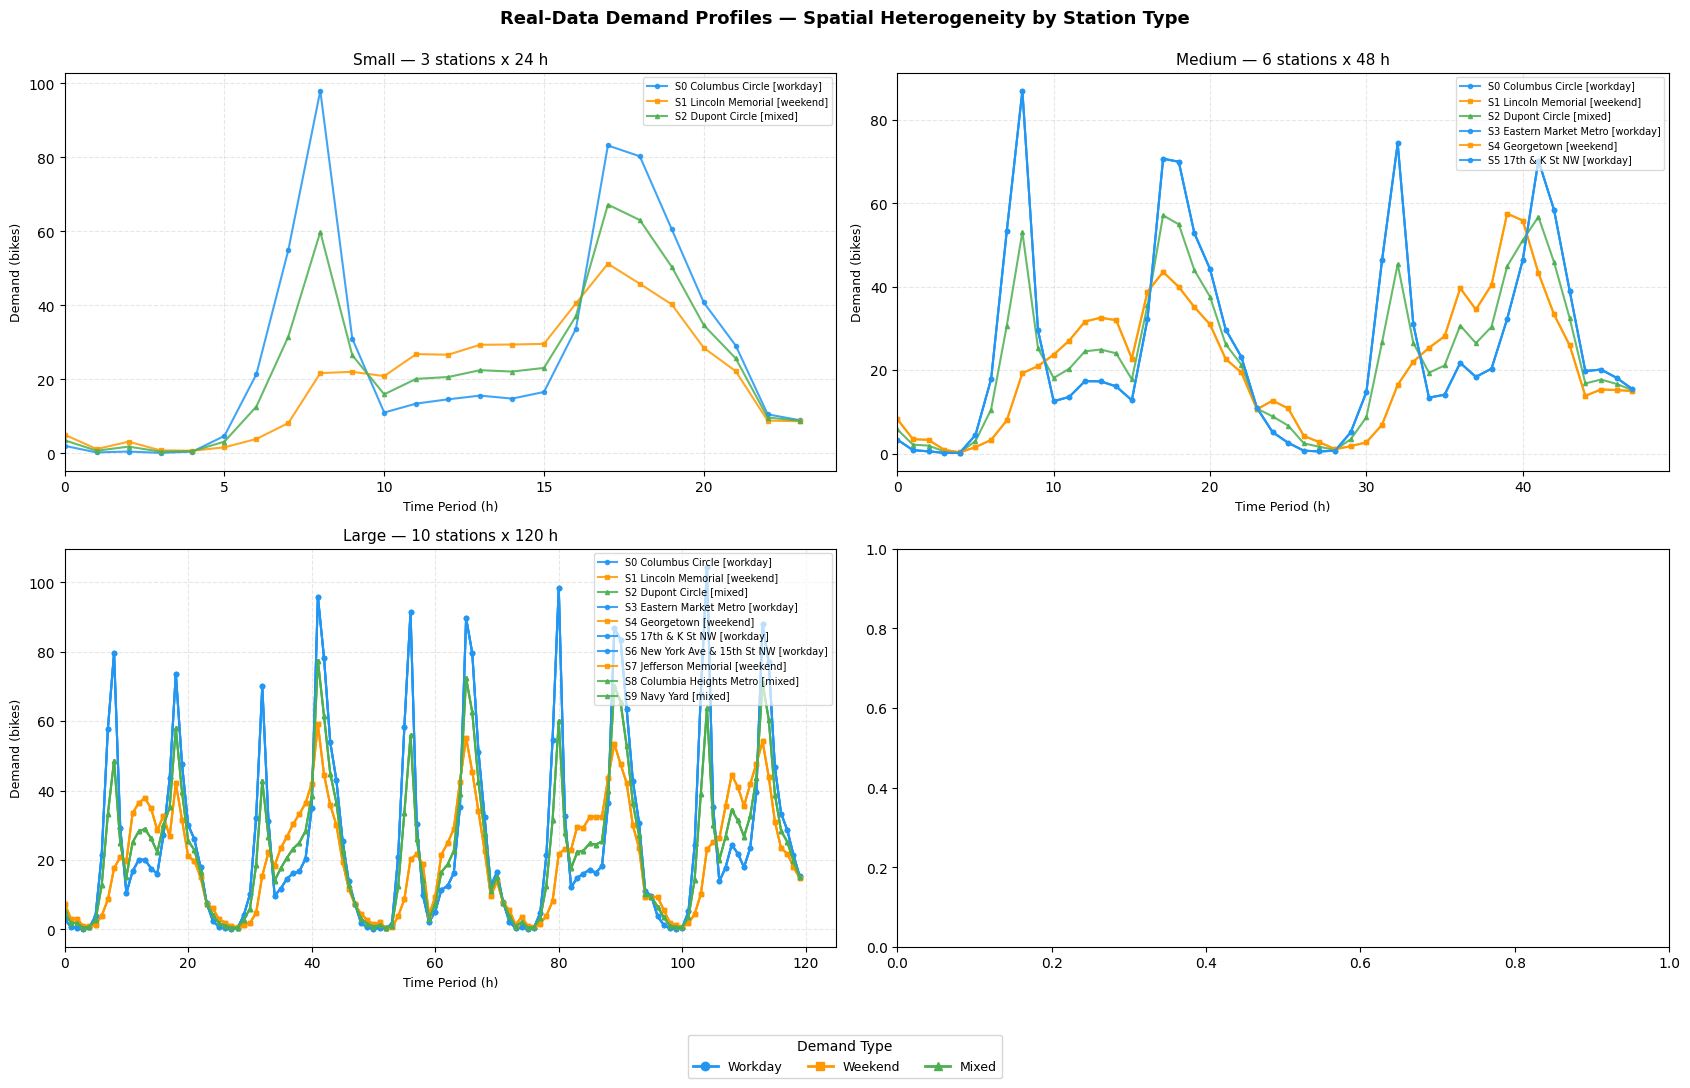

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Real-Data Demand Profiles — Spatial Heterogeneity by Station Type",
             fontsize=13, fontweight="bold", y=0.995)

COLOURS = {"workday": "#2196F3", "weekend": "#FF9800", "mixed": "#4CAF50"}
MARKERS = {"workday": "o", "weekend": "s", "mixed": "^"}

for idx, instance in enumerate(instances):
    demand = instance["demand"]
    meta   = instance["metadata"]
    ax     = axes.flatten()[idx]

    for s in range(meta["n_stations"]):
        d    = demand[:, s]
        dt   = meta["station_demand_types"][s]
        name = meta["station_names"][s].split("/")[0].strip()  # short label
        ax.plot(range(len(d)), d,
                color=COLOURS[dt], marker=MARKERS[dt],
                linewidth=1.5, markersize=3, alpha=0.85,
                label=f"S{s} {name} [{dt}]")

    ax.set_title(f"{meta['size'].capitalize()} — {meta['n_stations']} stations x {meta['n_time_periods']} h",
                 fontsize=11)
    ax.set_xlabel("Time Period (h)", fontsize=9)
    ax.set_ylabel("Demand (bikes)", fontsize=9)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.7)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xlim(left=0)

# Legend for demand types
handles = [Line2D([0],[0], color=c, marker=MARKERS[k], linewidth=2, markersize=6, label=k.capitalize())
           for k, c in COLOURS.items()]
fig.legend(handles=handles, title="Demand Type", loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.08), fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.show()


#### Solve all instances 

In [11]:
solutions = []
summary_rows = []

for idx, instance in enumerate(instances):
    meta = instance["metadata"]
    print(f"[{idx}] {meta['size'].upper()}  {meta['n_stations']} stations x {meta['n_time_periods']} periods", end="  ", flush=True)

    solver = MIPSolver(
        demand_sequence  = instance["demand"],
        capacity         = instance["capacity"],
        distance_matrix  = instance["distance_matrix"],
        constraints      = instance.get("constraints"),
        cost_per_km      = COST_PER_KM,
        penalty_per_bike = PENALTY_PER_BIKE,
    )
    solution = solver.solve()
    solutions.append(solution)

    total_dem = meta["total_demand"]
    imbalance_cost = getattr(solution, "imbalance_cost", 0.0)
    print(f"done  ({solution.solve_time:.2f}s)")

    summary_rows.append({
        "Instance": f"[{idx}] {meta['size'].upper()}",
        "Status": solution.status,
        "Total Cost ($)": f"{solution.cost:,.2f}",
        "Redistribution ($)": f"{solution.redistribution_cost:,.2f}  ({100 * solution.redistribution_cost / max(solution.cost, 1):.1f}%)",
        "Imbalance ($)": f"{imbalance_cost:,.2f}  ({100 * imbalance_cost / max(solution.cost, 1):.1f}%)",
        "Unmet Penalty ($)": f"{solution.unmet_demand_cost:,.2f}  ({solution.total_unmet_bikes:,} bikes x ${PENALTY_PER_BIKE})",
        "Unmet Demand": f"{solution.total_unmet_bikes:,} bikes  ({100 * solution.total_unmet_bikes / max(total_dem, 1):.2f}%)",
    })

display(pd.DataFrame(summary_rows).set_index("Instance"))

[0] SMALL  3 stations x 24 periods  done  (0.05s)
[1] MEDIUM  6 stations x 48 periods  done  (0.06s)
[2] LARGE  10 stations x 120 periods  done  (0.68s)


,Status,Total Cost ($),Redistribution ($),Imbalance ($),Unmet Penalty ($),Unmet Demand
Instance,,,,,,
[0] SMALL,OPTIMAL,171.08,105.91 (61.9%),65.17 (38.1%),0.00 (0 bikes x $50.0),0 bikes (0.00%)
[1] MEDIUM,OPTIMAL,"1,794.83","1,477.03 (82.3%)",317.81 (17.7%),0.00 (0 bikes x $50.0),0 bikes (0.00%)
[2] LARGE,OPTIMAL,"17,831.10","15,823.65 (88.7%)","2,007.45 (11.3%)",0.00 (0 bikes x $50.0),0 bikes (0.00%)


#### Results visualisation dashboard

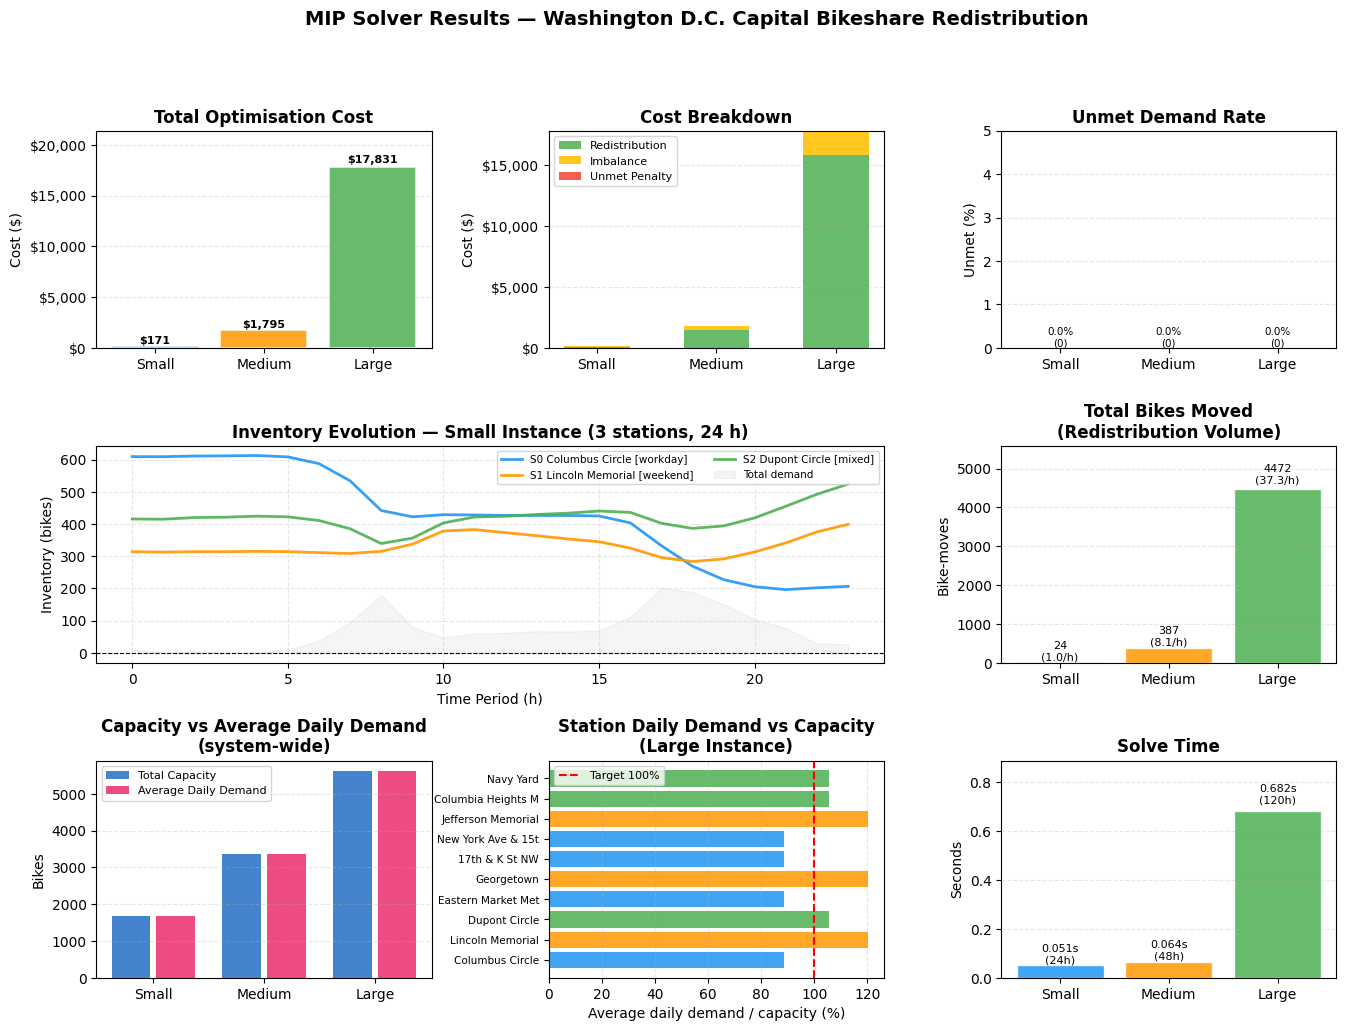

In [12]:
COLOURS  = {"workday": "#2196F3", "weekend": "#FF9800", "mixed": "#4CAF50"}
MARKERS  = {"workday": "o", "weekend": "s", "mixed": "^"}

instance_names  = [inst["metadata"]["size"].capitalize() for inst in instances]
costs           = [sol.cost for sol in solutions]
redistrib_costs = [sol.redistribution_cost for sol in solutions]
imbalance_costs = [getattr(sol, "imbalance_cost", 0.0) for sol in solutions]
unmet_costs     = [sol.unmet_demand_cost for sol in solutions]
unmet_bikes     = [sol.total_unmet_bikes for sol in solutions]
total_demands   = [inst["metadata"]["total_demand"] for inst in instances]
daily_demands   = [
    inst["metadata"]["total_demand"] / max(inst["metadata"]["n_time_periods"] / 24.0, 1.0)
    for inst in instances
]
solve_times     = [sol.solve_time for sol in solutions]
total_caps      = [float(np.sum(inst["capacity"])) for inst in instances]
bikes_moved_all = [float(np.sum(sol.redistribution_matrices)) for sol in solutions]

INST_COLOURS = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

fig = plt.figure(figsize=(16, 11))
fig.suptitle("MIP Solver Results — Washington D.C. Capital Bikeshare Redistribution",
             fontsize=14, fontweight="bold", y=0.99)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

#  1. Total cost 
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(instance_names, costs, color=INST_COLOURS, alpha=0.85, edgecolor="white", linewidth=1.2)
ax1.set_title("Total Optimisation Cost", fontweight='bold')
ax1.set_ylabel("Cost ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x:,.0f}"))
for bar, v in zip(bars, costs):
    label = f"${v/1e6:.2f}M" if v >= 1e6 else f"${v:,.0f}"
    ax1.text(bar.get_x() + bar.get_width()/2, v*1.01, label,
             ha="center", va="bottom", fontsize=8, fontweight='bold')
ax1.set_ylim(0, max(costs)*1.20 if max(costs) > 0 else 1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

#  2. Cost breakdown (stacked) 
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(instance_names))
w = 0.55
imbalance_bottom = np.array(redistrib_costs)
unmet_bottom = imbalance_bottom + np.array(imbalance_costs)
ax2.bar(x, redistrib_costs, w, label="Redistribution", color="#4CAF50", alpha=0.85)
ax2.bar(x, imbalance_costs, w, bottom=imbalance_bottom, label="Imbalance", color="#FFC107", alpha=0.9)
ax2.bar(x, unmet_costs, w, bottom=unmet_bottom, label="Unmet Penalty", color="#F44336", alpha=0.85)
ax2.set_title("Cost Breakdown", fontweight='bold')
ax2.set_ylabel("Cost ($)")
ax2.set_xticks(x); ax2.set_xticklabels(instance_names)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x:,.0f}"))
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

#  3. Unmet demand rate 
ax3 = fig.add_subplot(gs[0, 2])
pcts = [100 * u / max(d, 1) for u, d in zip(unmet_bikes, total_demands)]
bars3 = ax3.bar(instance_names, pcts, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax3.set_title("Unmet Demand Rate", fontweight='bold')
ax3.set_ylabel("Unmet (%)")
ax3.set_ylim(0, max(max(pcts)*1.25, 5))
for bar, p, u in zip(bars3, pcts, unmet_bikes):
    ax3.text(bar.get_x() + bar.get_width()/2, p + max(pcts)*0.02,
             f"{p:.1f}%\n({u:,})", ha="center", va="bottom", fontsize=7.5)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

#  4. Inventory evolution (small instance) 
ax4 = fig.add_subplot(gs[1, :2])
sol0    = solutions[0]
inst0   = instances[0]
meta0   = inst0["metadata"]
demand0 = inst0["demand"]
inv_seq = sol0.inventory_sequence

for s in range(meta0["n_stations"]):
    nm = meta0["station_names"][s].split("/")[0].strip()
    dt = meta0["station_demand_types"][s]
    ax4.plot(inv_seq[:, s], linewidth=2,
             color=COLOURS[dt], linestyle="-", label=f"S{s} {nm} [{dt}]", alpha=0.9)

# Shade total demand area
ax4.fill_between(range(meta0["n_time_periods"]),
                 demand0.sum(axis=1), alpha=0.08, color="gray", label="Total demand")
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_title(f"Inventory Evolution — Small Instance ({meta0['n_stations']} stations, {meta0['n_time_periods']} h)",
              fontweight='bold')
ax4.set_xlabel("Time Period (h)")
ax4.set_ylabel("Inventory (bikes)")
ax4.legend(fontsize=7.5, ncol=2, loc='upper right')
ax4.grid(alpha=0.3, linestyle='--')

#  5. Bikes moved vs scale 
ax5 = fig.add_subplot(gs[1, 2])
time_periods = [inst["metadata"]["n_time_periods"] for inst in instances]
ax5.bar(instance_names, bikes_moved_all, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax5.set_title("Total Bikes Moved\n(Redistribution Volume)", fontweight='bold')
ax5.set_ylabel("Bike-moves")
for i, (v, t) in enumerate(zip(bikes_moved_all, time_periods)):
    per_h = v / max(t, 1)
    ax5.text(i, v * 1.02 if v > 0 else 0.1, f"{v:.0f}\n({per_h:.1f}/h)",
             ha="center", va="bottom", fontsize=8)
ax5.set_ylim(0, max(bikes_moved_all) * 1.25 if max(bikes_moved_all) > 0 else 1)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

#  6. Capacity vs average daily demand 
ax6 = fig.add_subplot(gs[2, 0])
n_inst = len(instance_names)
ax6.bar([i - 0.2 for i in range(n_inst)], total_caps, 0.35,
        label="Total Capacity", color="#1565C0", alpha=0.8)
ax6.bar([i + 0.2 for i in range(n_inst)], daily_demands, 0.35,
        label="Average Daily Demand", color="#E91E63", alpha=0.8)
ax6.set_xticks(range(n_inst)); ax6.set_xticklabels(instance_names)
ax6.set_title("Capacity vs Average Daily Demand\n(system-wide)", fontweight='bold')
ax6.set_ylabel("Bikes")
ax6.legend(fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

#  7. Daily demand / capacity by station (large instance) 
ax7 = fig.add_subplot(gs[2, 1])
inst2   = instances[2]
meta2   = inst2["metadata"]
cap2    = inst2["capacity"]
demand2 = inst2["demand"]
days2   = max(meta2["n_time_periods"] / 24.0, 1.0)
utils2  = [np.sum(demand2[:, s]) / days2 / max(float(cap2[s]), 1) * 100
           for s in range(meta2["n_stations"])]
short_names = [meta2["station_names"][s].split("/")[0].strip()[:18]
               for s in range(meta2["n_stations"])]
dt_colours2 = [COLOURS[meta2["station_demand_types"][s]]
               for s in range(meta2["n_stations"])]
ax7.barh(range(meta2["n_stations"]), utils2, color=dt_colours2, alpha=0.85)
ax7.set_yticks(range(meta2["n_stations"]))
ax7.set_yticklabels(short_names, fontsize=7.5)
ax7.axvline(TARGET_UTILIZATION_RATIO * 100, color='red', linestyle='--', linewidth=1.5,
            label=f"Target {TARGET_UTILIZATION_RATIO:.0%}")
ax7.set_xlabel("Average daily demand / capacity (%)")
ax7.set_title("Station Daily Demand vs Capacity\n(Large Instance)", fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(axis='x', alpha=0.3, linestyle='--')

#  8. Solve time 
ax8 = fig.add_subplot(gs[2, 2])
ax8.bar(instance_names, solve_times, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax8.set_title("Solve Time", fontweight='bold')
ax8.set_ylabel("Seconds")
for i, (t, s) in enumerate(zip(time_periods, solve_times)):
    ax8.text(i, s * 1.03 if s > 0 else 0.001, f"{s:.3f}s\n({t}h)",
             ha="center", va="bottom", fontsize=8)
ax8.set_ylim(0, max(solve_times) * 1.3 if max(solve_times) > 0 else 1)
ax8.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig("results_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()

#### Total cost 

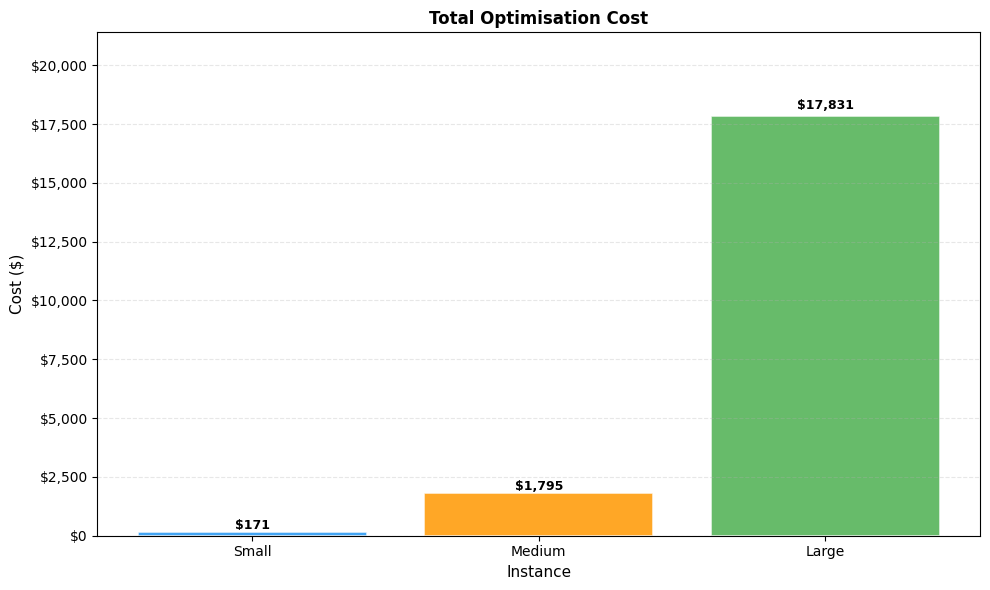

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(instance_names, costs, color=INST_COLOURS, alpha=0.85, edgecolor="white", linewidth=1.2)
ax1.set_title("Total Optimisation Cost", fontweight='bold', fontsize=12)
ax1.set_ylabel("Cost ($)", fontsize=11)
ax1.set_xlabel("Instance", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x:,.0f}"))
for bar, v in zip(bars, costs):
    label = f"${v/1e6:.2f}M" if v >= 1e6 else f"${v:,.0f}"
    ax1.text(bar.get_x() + bar.get_width()/2, v*1.01, label,
             ha="center", va="bottom", fontsize=9, fontweight='bold')
ax1.set_ylim(0, max(costs)*1.20 if max(costs) > 0 else 1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#### Cost breakdown (stacked)

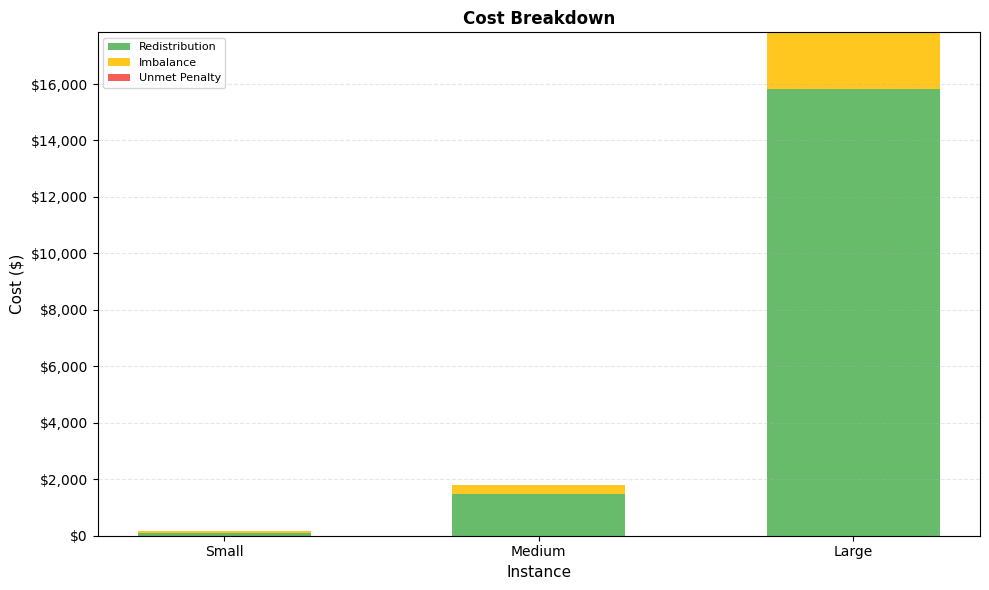

In [14]:
fig, ax2 = plt.subplots(figsize=(10, 6))
x = np.arange(len(instance_names))
w = 0.55
imbalance_bottom = np.array(redistrib_costs)
unmet_bottom = imbalance_bottom + np.array(imbalance_costs)
ax2.bar(x, redistrib_costs, w, label="Redistribution", color="#4CAF50", alpha=0.85)
ax2.bar(x, imbalance_costs, w, bottom=imbalance_bottom, label="Imbalance", color="#FFC107", alpha=0.9)
ax2.bar(x, unmet_costs, w, bottom=unmet_bottom, label="Unmet Penalty", color="#F44336", alpha=0.85)
ax2.set_title("Cost Breakdown", fontweight='bold', fontsize=12)
ax2.set_ylabel("Cost ($)", fontsize=11)
ax2.set_xlabel("Instance", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(instance_names)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x:,.0f}"))
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### Unmet demand rate

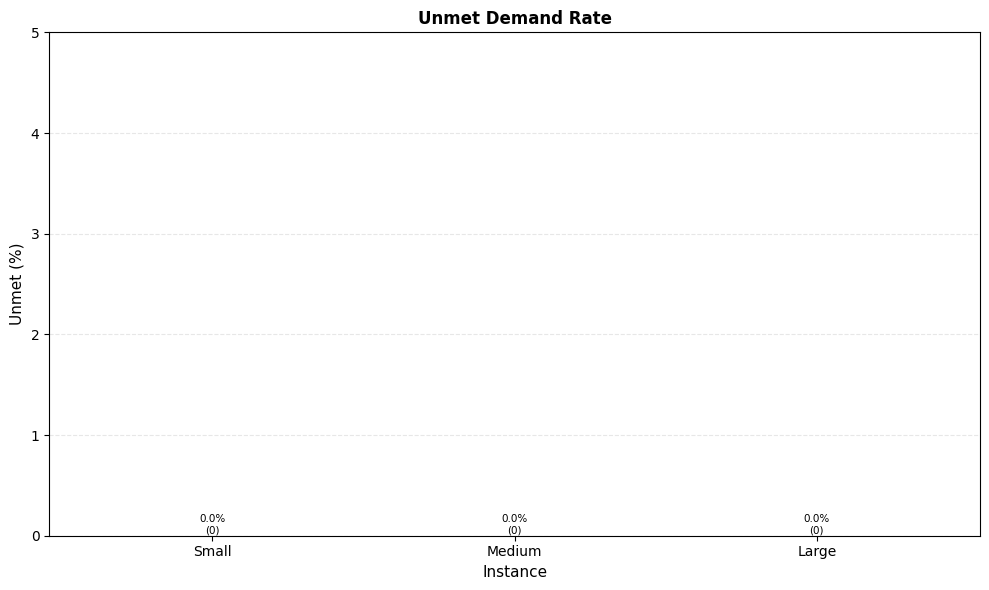

In [15]:
fig, ax3 = plt.subplots(figsize=(10, 6))
pcts = [100 * u / max(d, 1) for u, d in zip(unmet_bikes, total_demands)]
bars3 = ax3.bar(instance_names, pcts, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax3.set_title("Unmet Demand Rate", fontweight='bold', fontsize=12)
ax3.set_ylabel("Unmet (%)", fontsize=11)
ax3.set_xlabel("Instance", fontsize=11)
ax3.set_ylim(0, max(max(pcts)*1.25, 5))
for bar, p, u in zip(bars3, pcts, unmet_bikes):
    ax3.text(bar.get_x() + bar.get_width()/2, p + max(pcts)*0.02,
             f"{p:.1f}%\n({u:,})", ha="center", va="bottom", fontsize=7.5)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#### Inventory evolution

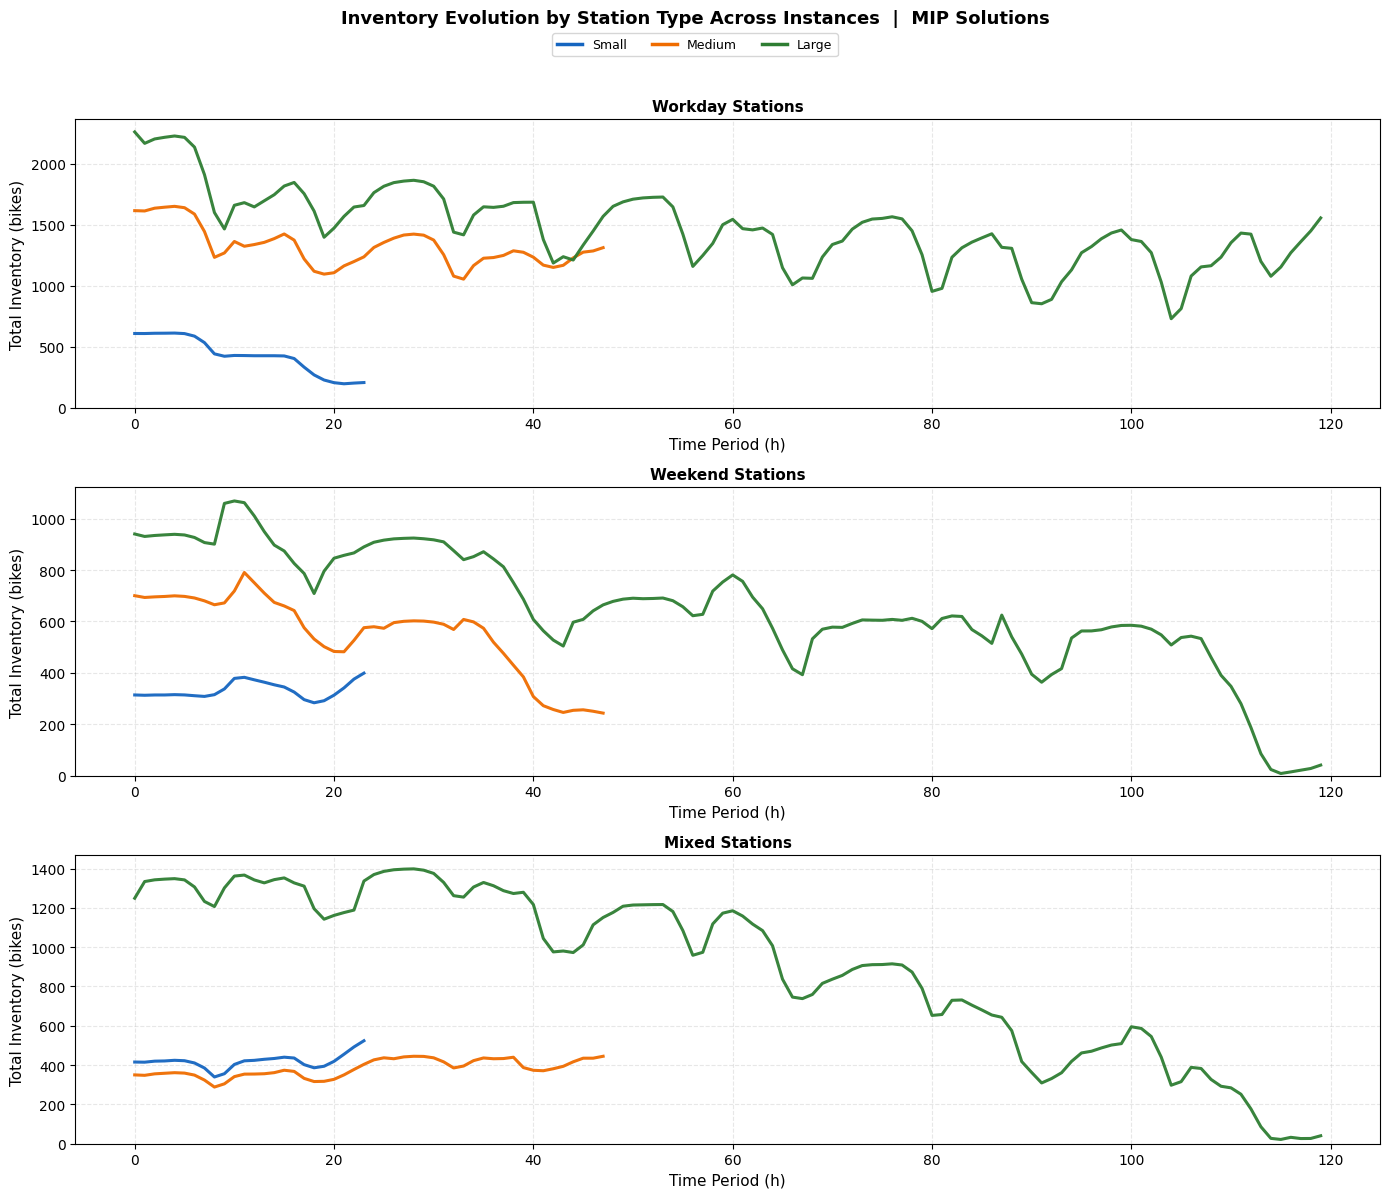

In [16]:
demand_types = ["workday", "weekend", "mixed"]
INSTANCE_COLOURS = ["#1565C0", "#EF6C00", "#2E7D32", "#8E24AA"]

fig, axes = plt.subplots(len(demand_types), 1, figsize=(14, 12), sharex=False)
if len(demand_types) == 1:
    axes = [axes]

instance_handles = []

for idx, (inst, sol) in enumerate(zip(instances, solutions)):
    meta = inst["metadata"]
    label = meta["size"].capitalize()
    colour = INSTANCE_COLOURS[idx % len(INSTANCE_COLOURS)]
    instance_handles.append(Line2D([0], [0], color=colour, linewidth=2.5, label=label))

    for ax, demand_type in zip(axes, demand_types):
        station_idx = [
            s for s, station_type in enumerate(meta["station_demand_types"])
            if station_type == demand_type
        ]
        if not station_idx:
            continue

        time_axis = range(meta["n_time_periods"])
        inventory_by_type = sol.inventory_sequence[:, station_idx].sum(axis=1)

        ax.plot(time_axis, inventory_by_type, linewidth=2.2,
                color=colour, alpha=0.95)

for ax, demand_type in zip(axes, demand_types):
    ax.set_title(f"{demand_type.capitalize()} Stations", fontweight="bold", fontsize=11)
    ax.set_xlabel("Time Period (h)", fontsize=11)
    ax.set_ylabel("Total Inventory (bikes)", fontsize=11)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3, linestyle="--")

fig.suptitle(
    "Inventory Evolution by Station Type Across Instances  |  MIP Solutions",
    fontweight="bold", fontsize=13, y=0.995,
 )
fig.legend(
    handles=instance_handles,
    fontsize=9, ncol=min(4, len(instance_handles)),
    loc="upper center", bbox_to_anchor=(0.5, 0.98), framealpha=0.8,
 )
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

#### Bikes moved vs scale

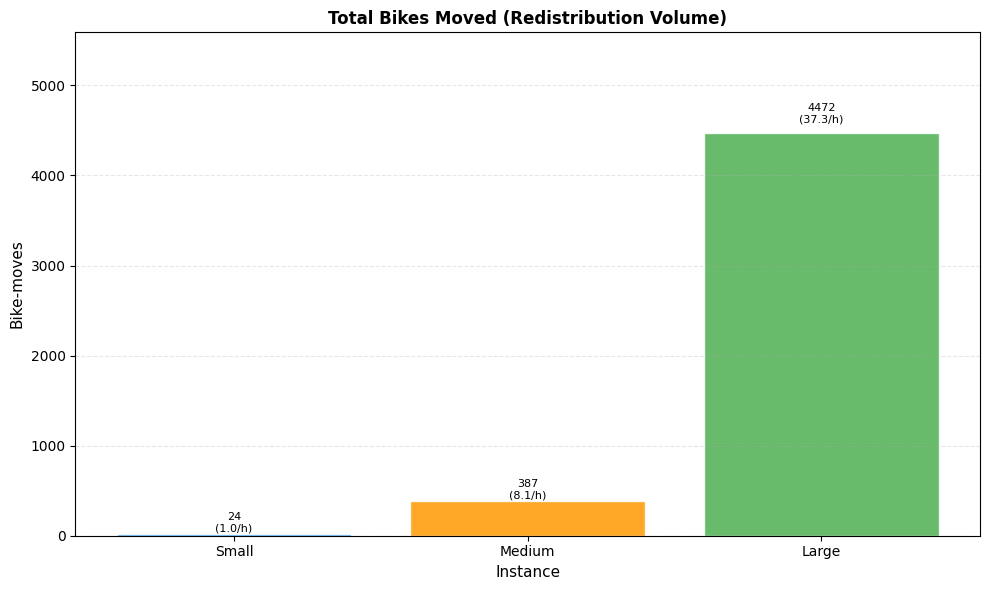

In [17]:
fig, ax5 = plt.subplots(figsize=(10, 6))
time_periods = [inst["metadata"]["n_time_periods"] for inst in instances]
ax5.bar(instance_names, bikes_moved_all, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax5.set_title("Total Bikes Moved (Redistribution Volume)", fontweight='bold', fontsize=12)
ax5.set_ylabel("Bike-moves", fontsize=11)
ax5.set_xlabel("Instance", fontsize=11)
for i, (v, t) in enumerate(zip(bikes_moved_all, time_periods)):
    per_h = v / max(t, 1)
    ax5.text(i, v * 1.02 if v > 0 else 0.1, f"{v:.0f}\n({per_h:.1f}/h)",
             ha="center", va="bottom", fontsize=8)
ax5.set_ylim(0, max(bikes_moved_all) * 1.25 if max(bikes_moved_all) > 0 else 1)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#### Demand vs capacity by instance

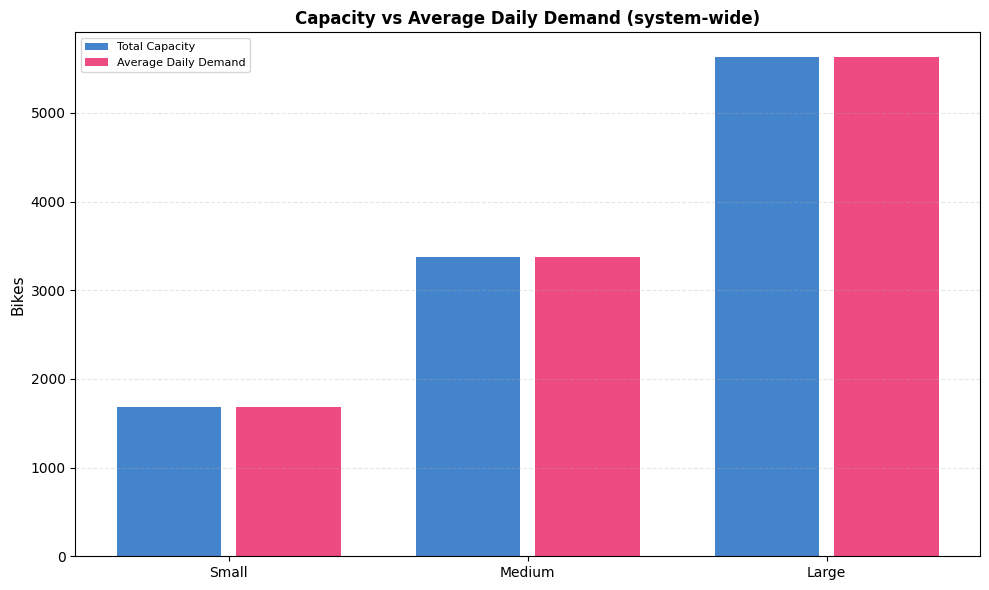

In [18]:
fig, ax6 = plt.subplots(figsize=(10, 6))
instance_names = [inst["metadata"]["size"].capitalize() for inst in instances]
total_caps = [float(np.sum(inst["capacity"])) for inst in instances]
daily_demands = [
    inst["metadata"]["total_demand"] / max(inst["metadata"]["n_time_periods"] / 24.0, 1.0)
    for inst in instances
]
n_inst = len(instance_names)
ax6.bar([i - 0.2 for i in range(n_inst)], total_caps, 0.35,
        label="Total Capacity", color="#1565C0", alpha=0.8)
ax6.bar([i + 0.2 for i in range(n_inst)], daily_demands, 0.35,
        label="Average Daily Demand", color="#E91E63", alpha=0.8)
ax6.set_xticks(range(n_inst))
ax6.set_xticklabels(instance_names)
ax6.set_title("Capacity vs Average Daily Demand (system-wide)", fontweight='bold', fontsize=12)
ax6.set_ylabel("Bikes", fontsize=11)
ax6.legend(fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#### Per-station utilisation

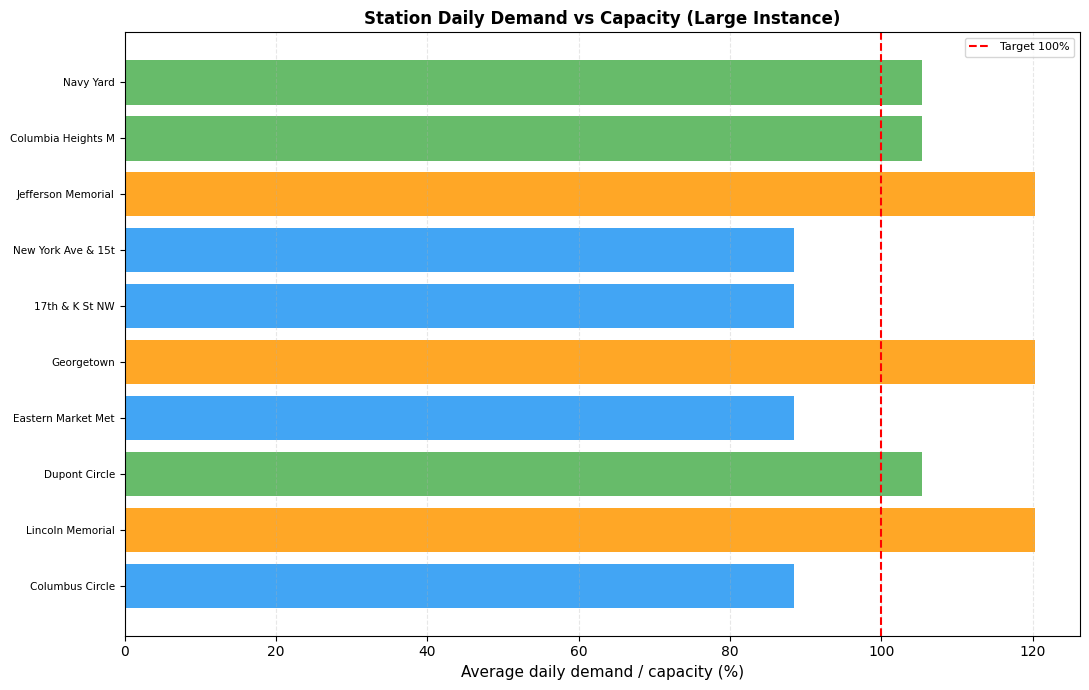

In [19]:
COLOURS = {"workday": "#2196F3", "weekend": "#FF9800", "mixed": "#4CAF50"}

fig, ax7 = plt.subplots(figsize=(11, 7))
inst2   = instances[2]
meta2   = inst2["metadata"]
cap2    = inst2["capacity"]
demand2 = inst2["demand"]
days2   = max(meta2["n_time_periods"] / 24.0, 1.0)
utils2  = [np.sum(demand2[:, s]) / days2 / max(float(cap2[s]), 1) * 100
           for s in range(meta2["n_stations"])]
short_names = [meta2["station_names"][s].split("/")[0].strip()[:18]
               for s in range(meta2["n_stations"])]
dt_colours2 = [COLOURS[meta2["station_demand_types"][s]]
               for s in range(meta2["n_stations"])]
ax7.barh(range(meta2["n_stations"]), utils2, color=dt_colours2, alpha=0.85)
ax7.set_yticks(range(meta2["n_stations"]))
ax7.set_yticklabels(short_names, fontsize=7.5)
ax7.axvline(TARGET_UTILIZATION_RATIO * 100, color='red', linestyle='--', linewidth=1.5,
            label=f"Target {TARGET_UTILIZATION_RATIO:.0%}")
ax7.set_xlabel("Average daily demand / capacity (%)", fontsize=11)
ax7.set_title("Station Daily Demand vs Capacity (Large Instance)", fontweight='bold', fontsize=12)
ax7.legend(fontsize=8)
ax7.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#### Solve time

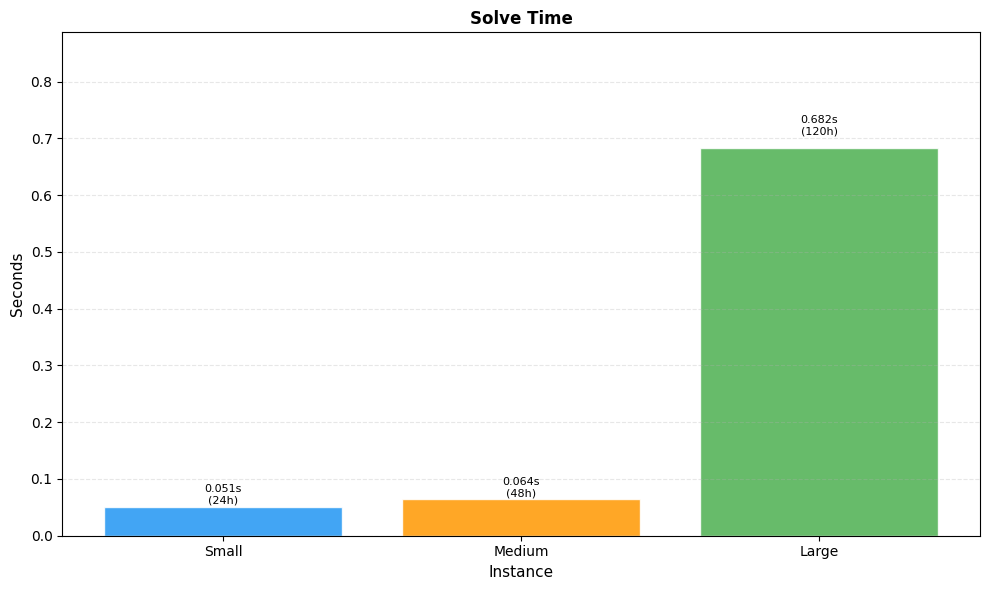

In [20]:
fig, ax8 = plt.subplots(figsize=(10, 6))
ax8.bar(instance_names, solve_times, color=INST_COLOURS, alpha=0.85, edgecolor="white")
ax8.set_title("Solve Time", fontweight='bold', fontsize=12)
ax8.set_ylabel("Seconds", fontsize=11)
ax8.set_xlabel("Instance", fontsize=11)
for i, (t, s) in enumerate(zip(time_periods, solve_times)):
    ax8.text(i, s * 1.03 if s > 0 else 0.001, f"{s:.3f}s\n({t}h)",
             ha="center", va="bottom", fontsize=8)
ax8.set_ylim(0, max(solve_times) * 1.3 if max(solve_times) > 0 else 1)
ax8.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


In [21]:
df = pd.DataFrame(REAL_STATION_CLUSTERS, columns=["name", "lat", "lon", "category"])
rt_lats, rt_lons = [], []
for i in range(len(REAL_STATION_CLUSTERS) - 1):
    s, e = REAL_STATION_CLUSTERS[i][1:3], REAL_STATION_CLUSTERS[i + 1][1:3]
    try:
        r = requests.get(
            f"http://router.project-osrm.org/route/v1/bike/{s[1]},{s[0]};{e[1]},{e[0]}?overview=full&geometries=geojson"
        ).json()
        if r.get("code") == "Ok":
            for lon, lat in r["routes"][0]["geometry"]["coordinates"]:
                rt_lats.append(lat)
                rt_lons.append(lon)
            rt_lats.append(None)
            rt_lons.append(None)
    except:
        pass
color_map = {"workday": "blue", "weekend": "green", "mixed": "orange"}
fig = px.scatter_map(
    df,
    lat="lat",
    lon="lon",
    color="category",
    hover_name="name",
    zoom=12,
    color_discrete_map=color_map,
    title="D.C. Bike Routes and Station ",
)
fig.update_traces(marker={"size": 15})
fig.add_trace(
    go.Scattermap(
        mode="lines",
        lon=rt_lons,
        lat=rt_lats,
        line={"width": 3, "color": "red"},
        name="Bike Route",
        hoverinfo="none",
    )
)
fig.update_layout(
    map_style="carto-darkmatter", margin={"r": 0, "t": 40, "l": 0, "b": 0}
)
fig.show()

In [22]:
## DP Solver Here

#### Genetic Algorithm Solver

In [23]:
ga_solutions = []
ga_summary_rows = []

for idx, instance in enumerate(instances):
    meta = instance["metadata"]
    print(f"[{idx}] {meta['size'].upper()}  {meta['n_stations']} stations x {meta['n_time_periods']} periods", end="  ", flush=True)

    ga_solver = GASolver(
        demand_sequence=instance["demand"],
        capacity=instance["capacity"],
        distance_matrix=instance["distance_matrix"],
        constraints=instance.get("constraints"),
        cost_per_km=COST_PER_KM,
        penalty_per_bike=PENALTY_PER_BIKE,
    )
    ga_sol = ga_solver.solve()
    ga_solutions.append(ga_sol)

    total_dem = meta["total_demand"]
    imbalance_cost = getattr(ga_sol, "imbalance_cost", 0.0)
    print(f"done  ({ga_sol.solve_time:.2f}s)")

    ga_summary_rows.append({
        "Instance": f"[{idx}] {meta['size'].upper()}",
        "Status": ga_sol.status,
        "Total Cost ($)": f"{ga_sol.cost:,.2f}",
        "Redistribution ($)": f"{ga_sol.redistribution_cost:,.2f}  ({100 * ga_sol.redistribution_cost / max(ga_sol.cost, 1):.1f}%)",
        "Imbalance ($)": f"{imbalance_cost:,.2f}  ({100 * imbalance_cost / max(ga_sol.cost, 1):.1f}%)",
        "Unmet Penalty ($)": f"{ga_sol.unmet_demand_cost:,.2f}  ({ga_sol.total_unmet_bikes:,} bikes x ${PENALTY_PER_BIKE})",
        "Unmet Demand": f"{ga_sol.total_unmet_bikes:,} bikes  ({100 * ga_sol.total_unmet_bikes / max(total_dem, 1):.2f}%)",
    })

display(pd.DataFrame(ga_summary_rows).set_index("Instance"))

[0] SMALL  3 stations x 24 periods  done  (29.77s)
[1] MEDIUM  6 stations x 48 periods  done  (59.37s)
[2] LARGE  10 stations x 120 periods  done  (125.83s)


,Status,Total Cost ($),Redistribution ($),Imbalance ($),Unmet Penalty ($),Unmet Demand
Instance,,,,,,
[0] SMALL,GA,69.35,2.91 (4.2%),66.44 (95.8%),0.00 (0 bikes x $50.0),0 bikes (0.00%)
[1] MEDIUM,GA,"4,189.20","3,777.82 (90.2%)",411.38 (9.8%),0.00 (0 bikes x $50.0),0 bikes (0.00%)
[2] LARGE,GA,"177,693.66","122,943.80 (69.2%)","2,567.08 (1.4%)","52,182.78 (1,043 bikes x $50.0)","1,043 bikes (3.71%)"


#### MIP vs GA Comparison

In [24]:
comparison_rows = []
for idx, (inst, mip_sol, ga_sol) in enumerate(zip(instances, solutions, ga_solutions)):
    meta = inst["metadata"]
    total_dem = meta["total_demand"]
    mip_unmet_pct = 100 * mip_sol.total_unmet_bikes / max(total_dem, 1)
    ga_unmet_pct = 100 * ga_sol.total_unmet_bikes / max(total_dem, 1)
    cost_gap_pct = 100 * (ga_sol.cost - mip_sol.cost) / max(mip_sol.cost, 1)
    comparison_rows.append({
        "Instance": f"[{idx}] {meta['size'].upper()}",
        "MIP Cost ($)": f"{mip_sol.cost:,.2f}",
        "GA Cost ($)": f"{ga_sol.cost:,.2f}",
        "Cost Gap (%)": f"{cost_gap_pct:+.1f}%",
        "MIP Unmet (%)": f"{mip_unmet_pct:.2f}%",
        "GA Unmet (%)": f"{ga_unmet_pct:.2f}%",
        "MIP Time (s)": f"{mip_sol.solve_time:.3f}",
        "GA Time (s)": f"{ga_sol.solve_time:.3f}",
    })

display(pd.DataFrame(comparison_rows).set_index("Instance"))

,MIP Cost ($),GA Cost ($),Cost Gap (%),MIP Unmet (%),GA Unmet (%),MIP Time (s),GA Time (s)
Instance,,,,,,,
[0] SMALL,171.08,69.35,-59.5%,0.00%,0.00%,0.051,29.769
[1] MEDIUM,"1,794.83","4,189.20",+133.4%,0.00%,0.00%,0.064,59.366
[2] LARGE,"17,831.10","177,693.66",+896.5%,0.00%,3.71%,0.682,125.829


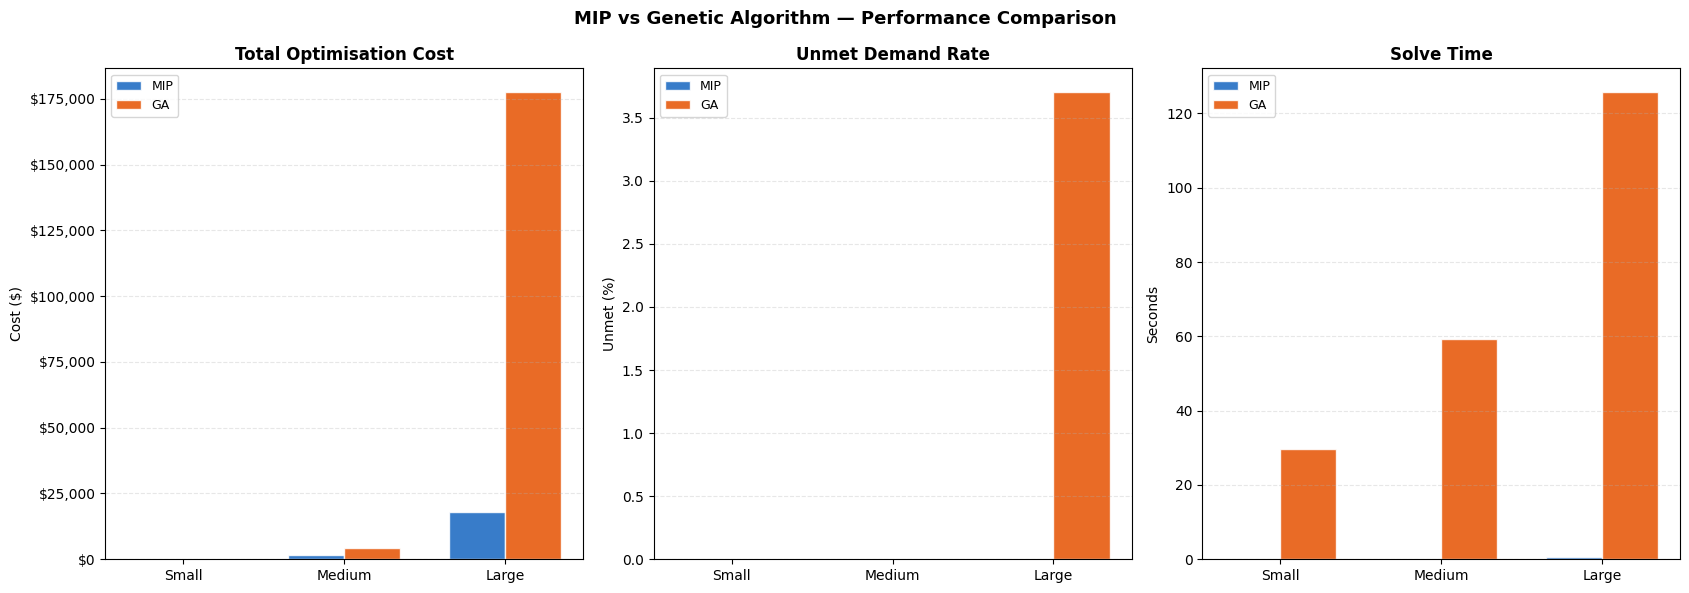

In [25]:
mip_costs = [sol.cost for sol in solutions]
ga_costs = [sol.cost for sol in ga_solutions]
mip_times = [sol.solve_time for sol in solutions]
ga_times = [sol.solve_time for sol in ga_solutions]
mip_unmet_pcts = [100 * sol.total_unmet_bikes / max(inst["metadata"]["total_demand"], 1)
                  for sol, inst in zip(solutions, instances)]
ga_unmet_pcts = [100 * sol.total_unmet_bikes / max(inst["metadata"]["total_demand"], 1)
                 for sol, inst in zip(ga_solutions, instances)]

x = np.arange(len(instance_names))
bar_width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("MIP vs Genetic Algorithm — Performance Comparison", fontsize=13, fontweight="bold")

ax = axes[0]
ax.bar(x - bar_width / 2, mip_costs, bar_width, label="MIP", color="#1565C0", alpha=0.85, edgecolor="white")
ax.bar(x + bar_width / 2, ga_costs, bar_width, label="GA", color="#E65100", alpha=0.85, edgecolor="white")
ax.set_title("Total Optimisation Cost", fontweight="bold")
ax.set_ylabel("Cost ($)")
ax.set_xticks(x)
ax.set_xticklabels(instance_names)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M" if v >= 1e6 else f"${v:,.0f}"))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")

ax = axes[1]
ax.bar(x - bar_width / 2, mip_unmet_pcts, bar_width, label="MIP", color="#1565C0", alpha=0.85, edgecolor="white")
ax.bar(x + bar_width / 2, ga_unmet_pcts, bar_width, label="GA", color="#E65100", alpha=0.85, edgecolor="white")
ax.set_title("Unmet Demand Rate", fontweight="bold")
ax.set_ylabel("Unmet (%)")
ax.set_xticks(x)
ax.set_xticklabels(instance_names)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")

ax = axes[2]
ax.bar(x - bar_width / 2, mip_times, bar_width, label="MIP", color="#1565C0", alpha=0.85, edgecolor="white")
ax.bar(x + bar_width / 2, ga_times, bar_width, label="GA", color="#E65100", alpha=0.85, edgecolor="white")
ax.set_title("Solve Time", fontweight="bold")
ax.set_ylabel("Seconds")
ax.set_xticks(x)
ax.set_xticklabels(instance_names)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("mip_vs_ga_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

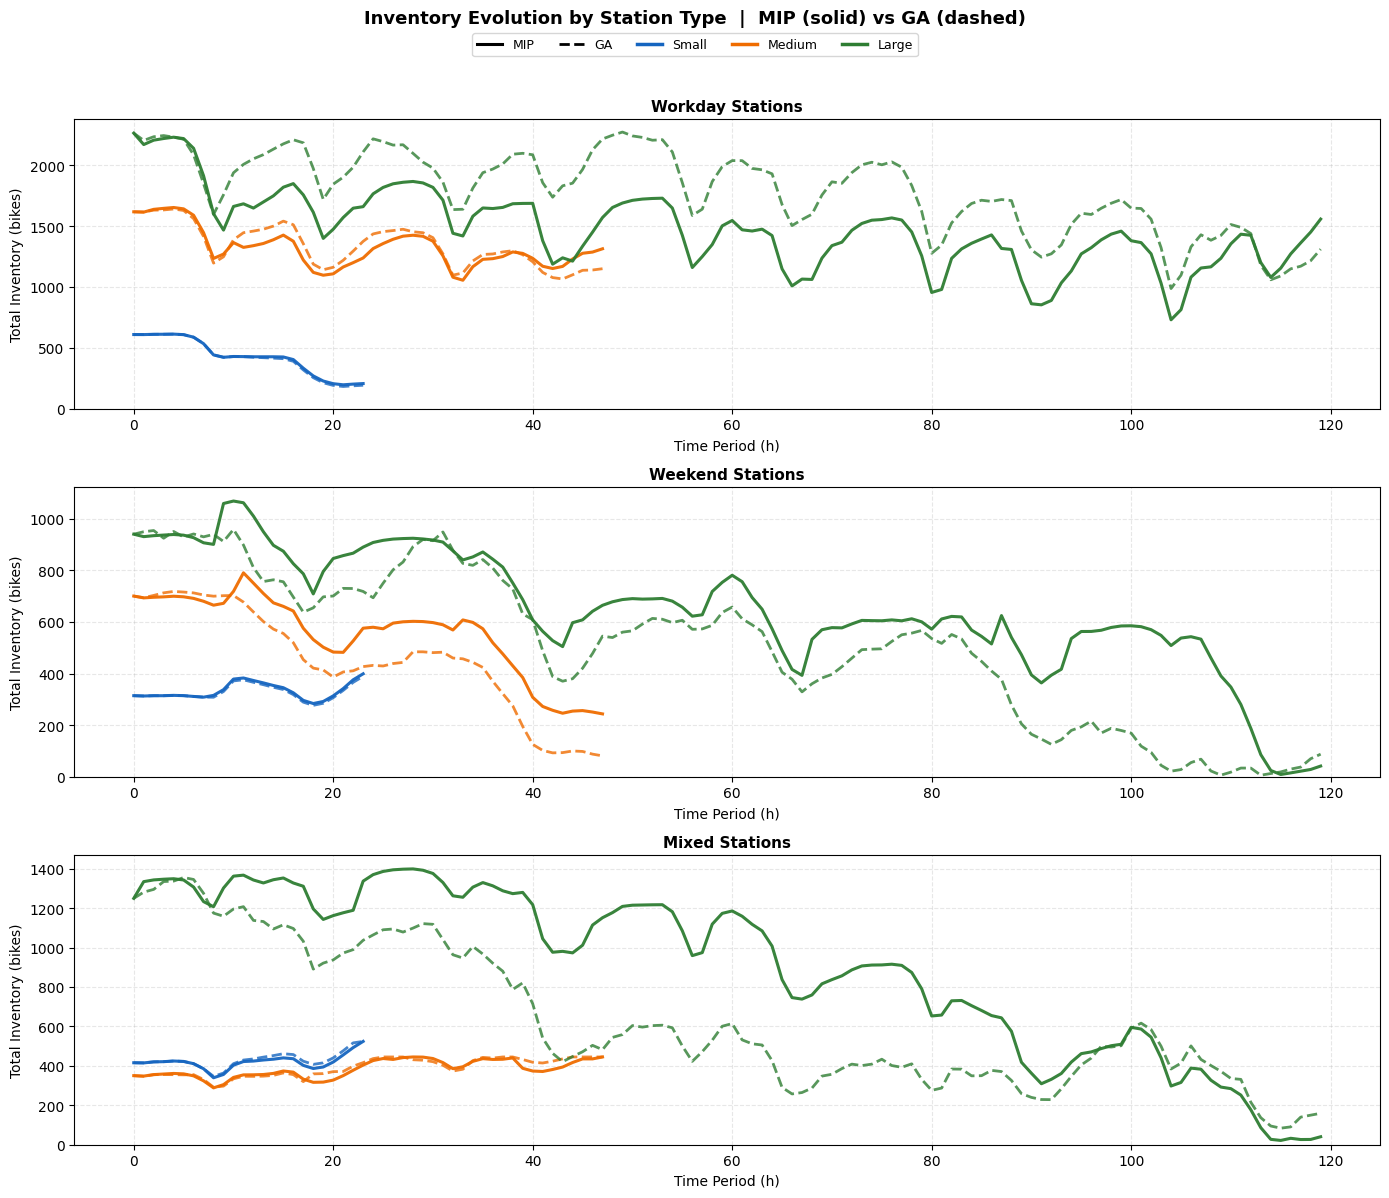

In [26]:
demand_types = ["workday", "weekend", "mixed"]
INSTANCE_COLOURS = ["#1565C0", "#EF6C00", "#2E7D32", "#8E24AA"]

fig, axes = plt.subplots(len(demand_types), 1, figsize=(14, 12), sharex=False)
if len(demand_types) == 1:
    axes = [axes]

style_handles = [
    Line2D([0], [0], color="black", linewidth=2.2, linestyle="-", label="MIP"),
    Line2D([0], [0], color="black", linewidth=2.0, linestyle="--", label="GA"),
]
instance_handles = []

for idx, (inst, mip_sol, ga_sol) in enumerate(zip(instances, solutions, ga_solutions)):
    meta = inst["metadata"]
    label = meta["size"].capitalize()
    colour = INSTANCE_COLOURS[idx % len(INSTANCE_COLOURS)]
    instance_handles.append(Line2D([0], [0], color=colour, linewidth=2.5, label=label))

    for ax, demand_type in zip(axes, demand_types):
        station_idx = [
            s for s, station_type in enumerate(meta["station_demand_types"])
            if station_type == demand_type
        ]
        if not station_idx:
            continue

        time_axis = range(meta["n_time_periods"])
        mip_inventory = mip_sol.inventory_sequence[:, station_idx].sum(axis=1)
        ga_inventory = ga_sol.inventory_sequence[:, station_idx].sum(axis=1)

        ax.plot(time_axis, mip_inventory, linewidth=2.2, linestyle="-",
                color=colour, alpha=0.95)
        ax.plot(time_axis, ga_inventory, linewidth=2.0, linestyle="--",
                color=colour, alpha=0.8)

for ax, demand_type in zip(axes, demand_types):
    ax.set_title(f"{demand_type.capitalize()} Stations", fontweight="bold", fontsize=11)
    ax.set_xlabel("Time Period (h)")
    ax.set_ylabel("Total Inventory (bikes)")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3, linestyle="--")

fig.suptitle(
    "Inventory Evolution by Station Type  |  MIP (solid) vs GA (dashed)",
    fontweight="bold", fontsize=13, y=0.995,
 )
fig.legend(
    handles=style_handles + instance_handles,
    fontsize=9, ncol=min(5, len(style_handles) + len(instance_handles)),
    loc="upper center", bbox_to_anchor=(0.5, 0.98), framealpha=0.8,
 )
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [27]:
importlib.reload(constraints_module)
importlib.reload(utils_module)
importlib.reload(dataloader_module)
importlib.reload(mipsolver_module)
importlib.reload(config_module)

MIPSolver = mipsolver_module.MIPSolver
load_bike_data = dataloader_module.load_bike_data
load_real_instances = dataloader_module.load_real_instances
COST_PER_KM = config_module.COST_PER_KM
PENALTY_PER_BIKE = config_module.PENALTY_PER_BIKE

hour_data_rt, day_data_rt = load_bike_data()
instances_rt = load_real_instances(hour_data_rt, day_data_rt)
small_instance = instances_rt[0]

solver_with_returns = MIPSolver(
    demand_sequence=small_instance["demand"],
    capacity=small_instance["capacity"],
    distance_matrix=small_instance["distance_matrix"],
    constraints=small_instance.get("constraints"),
    cost_per_km=COST_PER_KM,
    penalty_per_bike=PENALTY_PER_BIKE,
    initial_inventory=None,
 )
solution_with_returns = solver_with_returns.solve()

class NoReturnMIPSolver(MIPSolver):
    def _hourly_return_rate(self, hour: int) -> float:
        return 0.0

solver_without_returns = NoReturnMIPSolver(
    demand_sequence=small_instance["demand"],
    capacity=small_instance["capacity"],
    distance_matrix=small_instance["distance_matrix"],
    constraints=small_instance.get("constraints"),
    cost_per_km=COST_PER_KM,
    penalty_per_bike=PENALTY_PER_BIKE,
    initial_inventory=None,
 )
solution_without_returns = solver_without_returns.solve()

# Prepare summary data for display
return_comparison_data = [
    {
        "Scenario": "With returns (cross-station)",
        "Status": solution_with_returns.status,
        "Total Cost ($)": f"{solution_with_returns.cost:,.2f}",
        "Redistribution ($)": f"{solution_with_returns.redistribution_cost:,.2f}",
        "Imbalance ($)": f"{solution_with_returns.imbalance_cost:,.2f}",
        "Unmet Bikes": f"{solution_with_returns.total_unmet_bikes:,}",
        "Solve Time (s)": f"{solution_with_returns.solve_time:.3f}"
    },
    {
        "Scenario": "Without returns (demand-only)",
        "Status": solution_without_returns.status,
        "Total Cost ($)": f"{solution_without_returns.cost:,.2f}",
        "Redistribution ($)": f"{solution_without_returns.redistribution_cost:,.2f}",
        "Imbalance ($)": f"{solution_without_returns.imbalance_cost:,.2f}",
        "Unmet Bikes": f"{solution_without_returns.total_unmet_bikes:,}",
        "Solve Time (s)": f"{solution_without_returns.solve_time:.3f}"
    }
]

print(f"Return Config: lag={config_module.RETURN_LAG_HOURS}h, scale={config_module.RETURN_RATE_SCALE:.2f}, decay={config_module.RETURN_DISTANCE_DECAY_KM:.1f} km\n")
display(pd.DataFrame(return_comparison_data).set_index("Scenario"))
print(f"\nCost improvement from return modeling: ${solution_without_returns.cost - solution_with_returns.cost:,.2f}")

Loaded hourly data from UCI: 17379 rows, 16 columns
  Columns: dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt  
Created daily aggregation: 731 rows

Extracting mathematical constraints for capacity calculation...
  Hourly profiles computed from real data:
    workday: peak hour=17:00, max=525, min=5
    weekend: peak hour=13:00, max=373, min=8
    mixed  : peak hour=17:00, max=424, min=7
Instance 0 (small): 3 stations, 24h
  Real dates : 2011-05-19
  Cnt range  : 4-547
  Station 0 [workday]: Columbus Circle / Union Station
  Station 1 [weekend]: Lincoln Memorial
  Station 2 [mixed  ]: Dupont Circle
  Capacity   : min=399, max=764
  Total demand (scaled to 100% utilization): 1687
Instance 1 (medium): 6 stations, 48h
  Real dates : 2011-05-26, 2011-05-27
  Cnt range  : 2-494
  Station 0 [workday]: Columbus Circle / Union Station
  Station 1 [weekend]: Lincoln Memorial
  Station 2 [mixed  ]: Dupont Circle
  Station 3 [workday]: Eas

,Status,Total Cost ($),Redistribution ($),Imbalance ($),Unmet Bikes,Solve Time (s)
Scenario,,,,,,
With returns (cross-station),OPTIMAL,171.08,105.91,65.17,0,0.012
Without returns (demand-only),OPTIMAL,"17,002.22",0.00,132.22,337,0.006



Cost improvement from return modeling: $16,831.14
